# Multimodal Animal Detection Demo

This notebook demonstrates a multimodal pipeline that processes:

- Text input (animal extraction using NER)
- Image input (animal classification using CNN)

The system checks whether the animal mentioned in the text matches the animal shown in the image.

## Pipeline Overview

The system consists of two models:

1. **NER model**
   - Transformer-based model (DistilBERT)
   - Extracts animal names from text.

2. **Image classifier**
   - CNN based on ResNet18
   - Classifies animals from images.

The final pipeline compares the extracted animal from text with the predicted animal from the image and outputs a boolean result.

In [53]:
# Function to run the pipeline with given text and image, and display the image in the notebook
from IPython.display import display
from PIL import Image

def run_pipeline(text, image):

    img = Image.open(image)
    img.thumbnail((300, 300))  
    display(img)
    
    !python pipeline.py --text "{text}" --image "{image}"

## Example 1: Correct match

Text mentions a cat and the image contains a cat.
Expected result: True

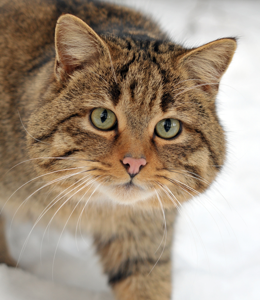

Loading models.

Step 1: NER
Animals extracted from text: cat

Step 2: Image Classification
Predicted class: cat
Confidence: 1.000

Step 3: Matching
Final Result: True



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5845.49it/s]


In [54]:
run_pipeline(
    "This is a beautiful cat",
    "images/cat.jpg"
)

## Example 2: Mismatch

Text mentions a dog but the image contains a sheep.
Expected result: False

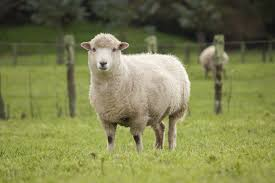

Loading models.

Step 1: NER
Animals extracted from text: dog

Step 2: Image Classification
Predicted class: sheep
Confidence: 1.000

Step 3: Matching
Final Result: False



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5858.99it/s]


In [55]:
run_pipeline(
    "I think it is a dog",
    "images/sheep.jpg"
)

## Example 3: No animal mentioned in text

If the text does not contain an animal name, the NER model returns an empty list and the final result is False.

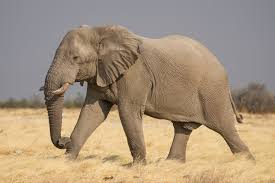

Loading models.

Step 1: NER
No animals detected in the text.

Step 2: Image Classification
Predicted class: elephant
Confidence: 1.000

Step 3: Matching
Final Result: False



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5396.16it/s]


In [59]:
run_pipeline(
    "I like sunny weather",
    "images/elephant.jpg"
)

## Example 4: Multiple animals mentioned

If multiple animals are detected in text, the pipeline checks if the predicted image class matches any of them.

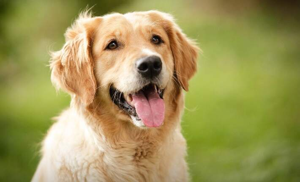

Loading models.

Step 1: NER
Animals extracted from text: dog, cat

Step 2: Image Classification
Predicted class: dog
Confidence: 1.000

Step 3: Matching
Final Result: True



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5388.80it/s]


In [57]:
run_pipeline(
    "I saw a dog and a cat in the park",
    "images/dog.jpg"
)

## Example 5: Uncertain text descriptions

The NER model may extract animals from uncertain phrases such as "maybe it's a dog".

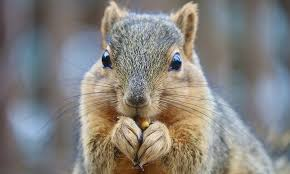

Loading models.

Step 1: NER
Animals extracted from text: squirrel

Step 2: Image Classification
Predicted class: squirrel
Confidence: 1.000

Step 3: Matching
Final Result: True



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5380.19it/s]


In [58]:
run_pipeline(
    "I'm not sure, but maybe it is a squirrel",
    "images/squirrel.jpg"
)

## Conclusion

This demo illustrates a simple multimodal system that combines natural language processing and computer vision.

The pipeline successfully extracts animal entities from text, classifies images, and verifies whether both inputs describe the same animal.